# Лабораторная работа №5
Поток: РНИФ (3к_Нейротех) 1.1

Выполнили:

Егорова Варвара 408575

Ташкинова Татьяна 413084

Аббясов Радислам 367038

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import zscore

ALPHA_FILES = {
    "Закрытые глаза": "/content/closed_eyes_alpha_EEG.dat",
    "Игра":           "/content/game_alpha_EEG.dat",
    "Музыка":         "/content/music_alpha_EEG.dat",
}
BETA_FILES = {
    "Закрытые глаза": "/content/closed_eyes_betha_EEG.dat",
    "Игра":           "/content/game_betha_EEG.dat",
    "Музыка":         "/content/music_betha_EEG.dat",
}

ALPHA_LO, ALPHA_HI = 8,  13
BETA_LO,  BETA_HI  = 13, 30
Z_THRESH            = 2.5
SMOOTH_WIN          = 101
WIN_SEC, STEP_SEC   = 2.0, 0.5
COLORS = {"Закрытые глаза": "steelblue", "Игра": "tomato", "Музыка": "mediumseagreen"}


def load(path):
    return pd.read_csv(path, sep="\t", header=None, names=["t", "a"])

def clean(df):
    df = df.dropna().drop_duplicates(subset="t").sort_values("t").reset_index(drop=True)
    for _ in range(2):
        df = df[np.abs(zscore(df["a"])) < Z_THRESH].reset_index(drop=True)
    return df

def get_fs(t):
    return 1.0 / np.median(np.diff(t))

def smooth(a):
    win = min(SMOOTH_WIN, len(a) // 2 * 2 - 1)
    return savgol_filter(a, window_length=win, polyorder=3)

# Скользящая мощность в диапазоне
def rolling_power(t, a, fs, flo, fhi):
    win, step = int(WIN_SEC * fs), int(STEP_SEC * fs)
    times, powers = [], []
    for i in range(0, len(a) - win, step):
        seg = a[i:i+win] - a[i:i+win].mean()
        fft_v = np.abs(np.fft.rfft(seg))
        freqs = np.fft.rfftfreq(win, d=1/fs)
        powers.append(fft_v[(freqs >= flo) & (freqs <= fhi)].mean())
        times.append(t[i + win // 2])
    return np.array(times), np.array(powers)

# Полный спектр мощности
def psd(a, fs):
    freqs = np.fft.rfftfreq(len(a), d=1/fs)
    power = np.abs(np.fft.rfft(a - a.mean())) ** 2
    return freqs, power

# аппроксимация
def poly_fit(t, a, deg=5):
    t_n = (t - t[0]) / (t[-1] - t[0])
    fit = np.poly1d(np.polyfit(t_n, a, deg))(t_n)
    r2  = 1 - np.sum((a - fit)**2) / np.sum((a - a.mean())**2)
    return fit, r2

# Полный спектр мощности
def full_spectrum(a, fs):
    a_centered = a - a.mean()
    fft_v = np.abs(np.fft.rfft(a_centered)) ** 2
    freqs = np.fft.rfftfreq(len(a), d=1/fs)
    return freqs, fft_v


## Очистка альфа волн
Альфа волны в исходных данных вполне чистые, тем не менее перед анализом обработаем их для более легкой работы.

Сначала загружаем сырые данные и показываем их как есть — со всеми шумами и артефактами.
Сначала убирем дубликаты по времени и выбросы с помощью стандартного z-score. Проведем сглаживание с помощью фильтра Савицкого-Голея (он лучше сохраняет форму оригинального сигнала).

С помощью аппроксимация можем показать общее поведение сигнала более наглядно (растёт активность или падает).
R² показывает насколько хорошо полином описывает данные (чем ближе к 1, тем лучше).

 
Обработка альфа волн

 [Закрытые глаза] R²=0.6591


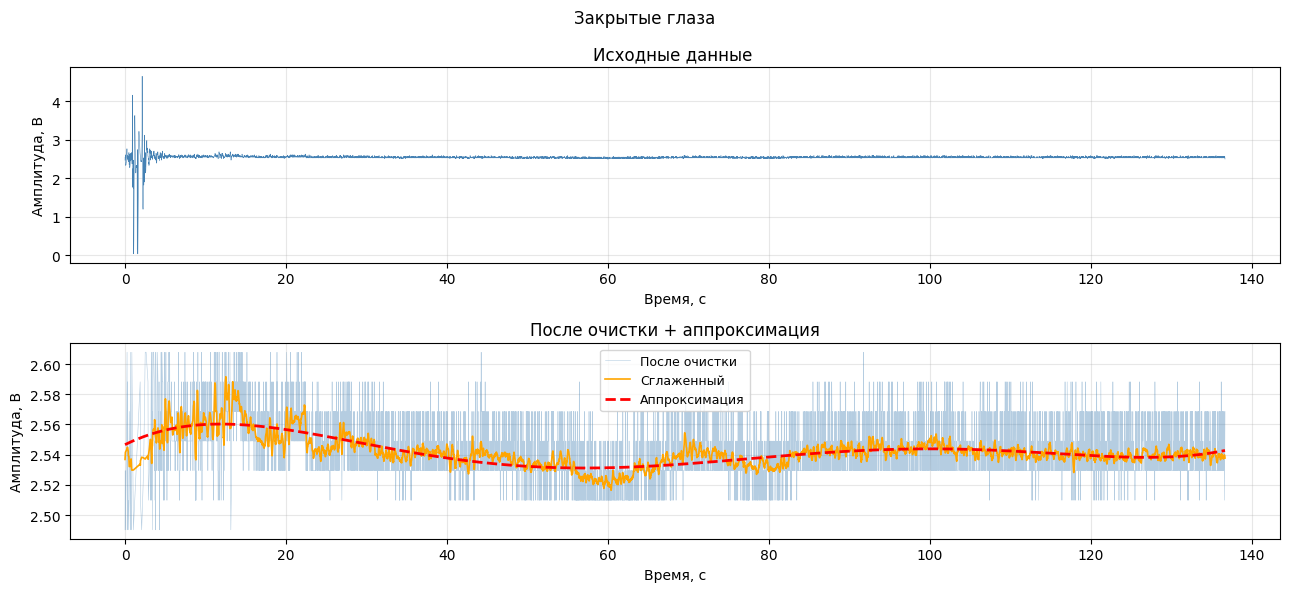


 [Игра] R²=0.1576


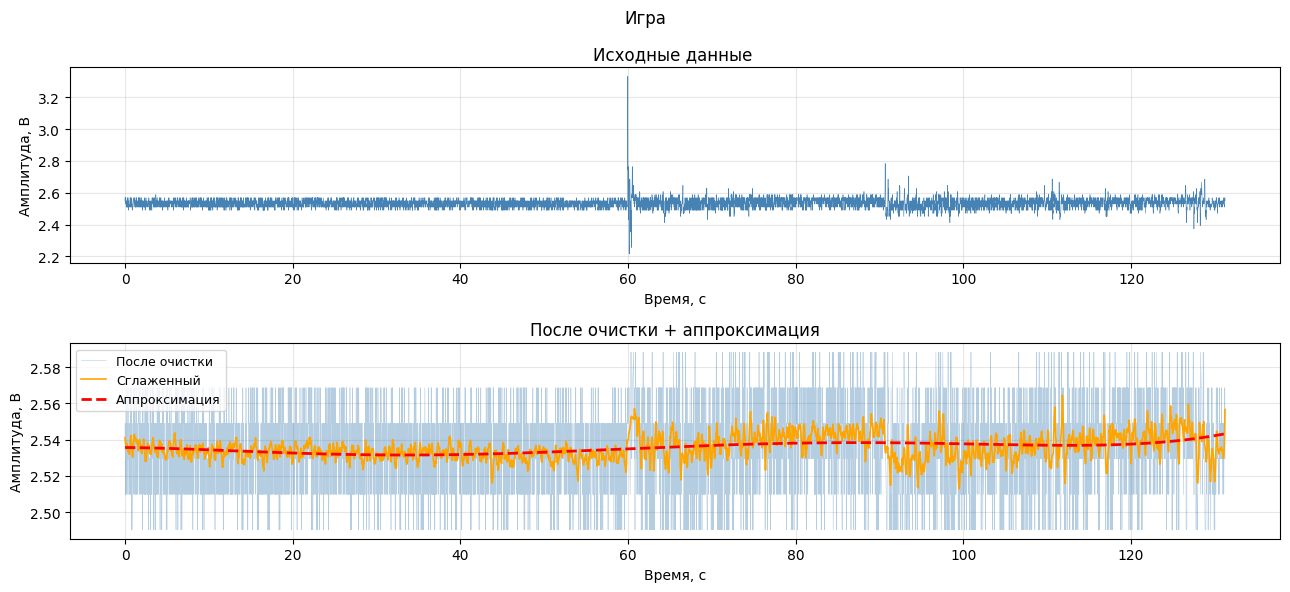


 [Музыка] R²=0.0592


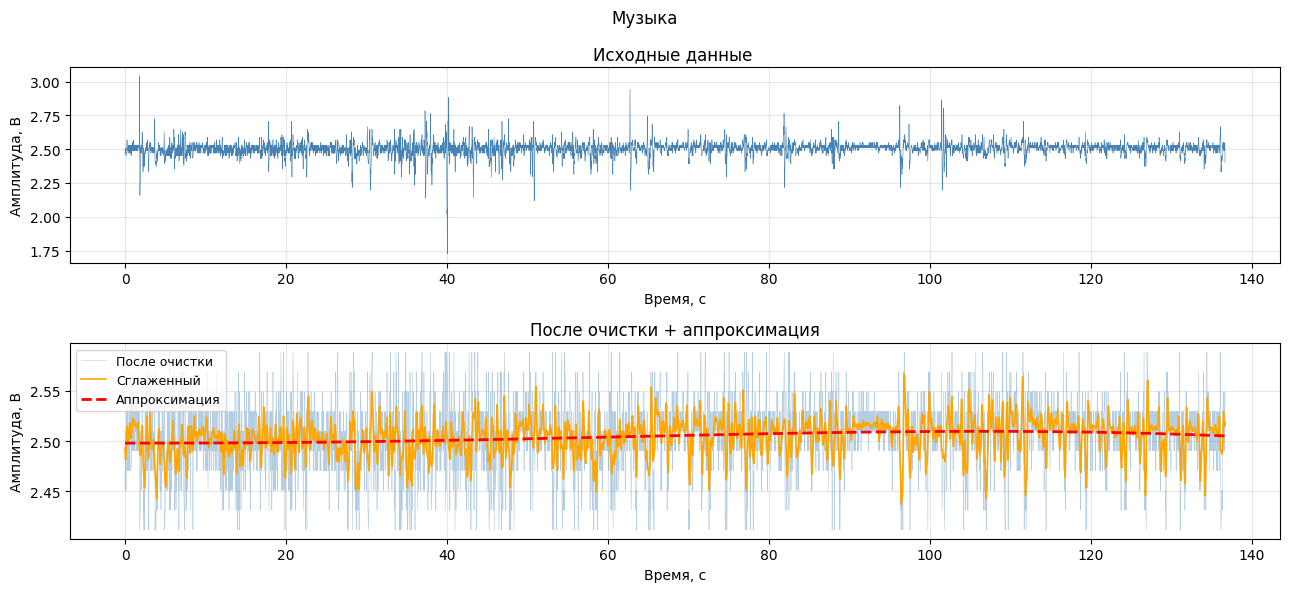

In [ ]:
print(" ")
print("Обработка альфа волн")


for state, path in ALPHA_FILES.items():
    raw = load(path)
    df  = clean(raw)
    t   = df["t"].to_numpy()
    a   = df["a"].to_numpy()
    a_sm = smooth(a)
    fit, r2 = poly_fit(t[::5], a_sm[::5])

    print(f"\n [{state}] R²={r2:.4f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6))
    fig.suptitle(f"{state}")

    ax1.plot(raw["t"].to_numpy()[::5] - raw["t"].iloc[0],
             raw["a"].to_numpy()[::5], color="steelblue", linewidth=0.4)
    ax1.set_title(f"Исходные данные ")
    ax1.set_ylabel("Амплитуда, В"); ax1.set_xlabel("Время, с")
    ax1.grid(True, alpha=0.3)

    t_rel = t - t[0]
    ax2.plot(t_rel[::5], a[::5], color="steelblue", lw=0.4, alpha=0.4, label="После очистки")
    ax2.plot(t_rel[::5], a_sm[::5], color="orange", lw=1.2, label="Сглаженный")
    ax2.plot(t_rel[::5], fit, color="red", lw=2.0, ls="--",
             label=f"Аппроксимация")
    ax2.set_title(f"После очистки + аппроксимация")
    ax2.set_ylabel("Амплитуда, В"); ax2.set_xlabel("Время, с")
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


## Очистка бета волн

Из-за высокой частоты на обычном графике амплитуды они выглядят как шум, поэтому смотреть на амплитуду бета-сигнала бессмысленно.

Сделаем вывод скользящей спектральной мощности. Она делит запись на короткие окна, на каждом окне считает преобразование Фурье и суммирует мощность.
Получаем кривую мощности во времени, которая показывает когда мозг был более или менее активен.
Полиномиальная аппроксимация поверх сглаженной мощности показывает общий тренд активности за всё время записи.



Обработка бета волн

  [Закрытые глаза] R²=0.9816


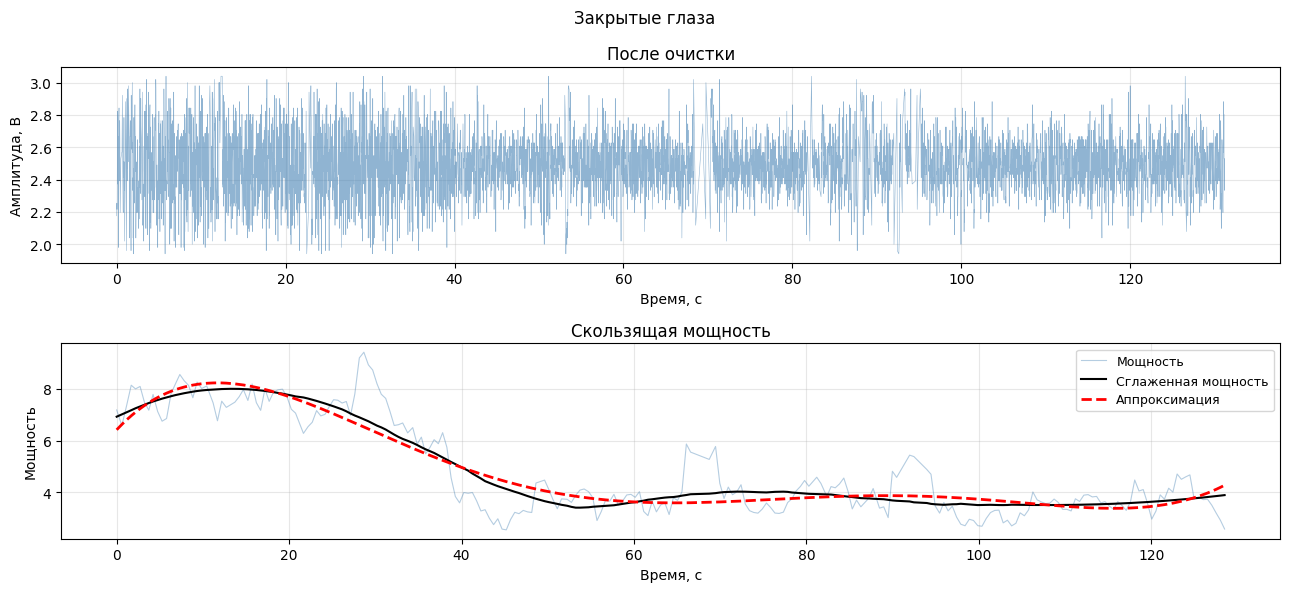


  [Игра] R²=0.8448


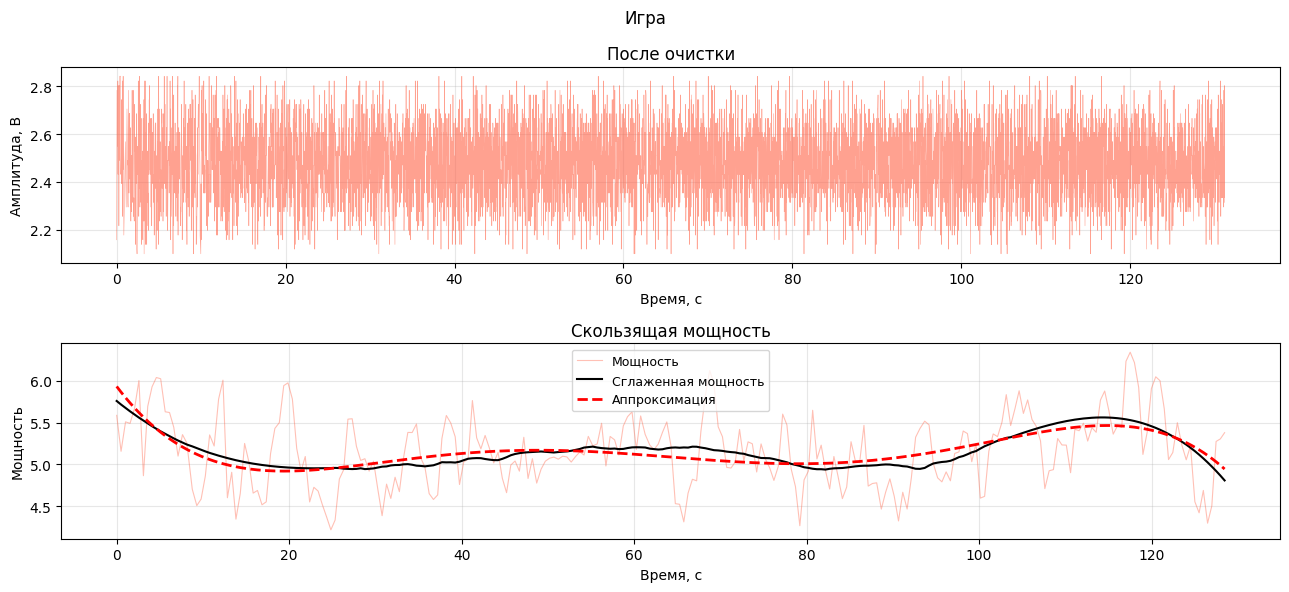


  [Музыка] R²=0.8193


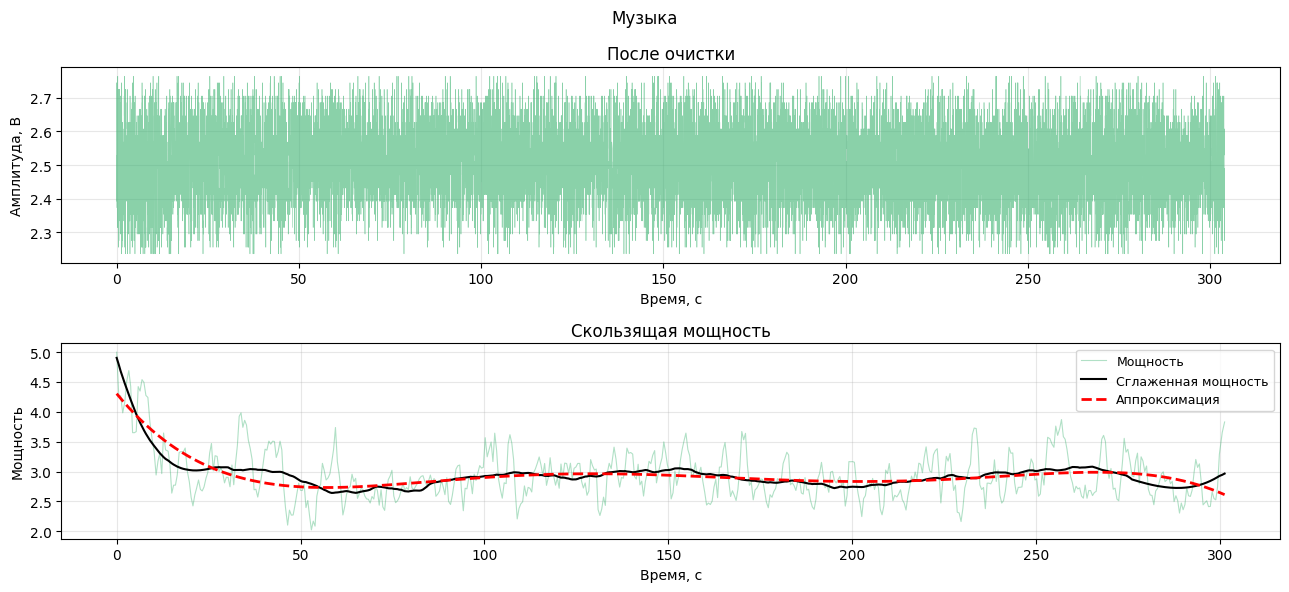

In [ ]:

print("\n")
print("Обработка бета волн")

for state, path in BETA_FILES.items():
    raw = load(path)
    df  = clean(raw)
    t   = df["t"].to_numpy()
    a   = df["a"].to_numpy()
    fs  = get_fs(t)

    pt, pw  = rolling_power(t, a, fs, BETA_LO, BETA_HI)
    pt_rel  = pt - pt[0]
    pw_sm   = smooth(pw)
    fit, r2 = poly_fit(pt_rel, pw_sm)

    print(f"\n  [{state}] R²={r2:.4f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6))
    fig.suptitle(f"{state}",)

    t_rel_full = t - t[0]
    ax1.plot(t_rel_full[::5], a[::5], color=COLORS[state], lw=0.4, alpha=0.6)
    ax1.set_title(f"После очистки")
    ax1.set_ylabel("Амплитуда, В"); ax1.set_xlabel("Время, с")
    ax1.grid(True, alpha=0.3)

    ax2.plot(pt_rel, pw, color=COLORS[state], lw=0.8, alpha=0.4, label="Мощность")
    ax2.plot(pt_rel, pw_sm, color="black", lw=1.5, label="Сглаженная мощность")
    ax2.plot(pt_rel, fit, color="red", lw=2.0, ls="--",
             label=f"Аппроксимация")
    ax2.set_title(f"Скользящая мощность")
    ax2.set_ylabel("Мощность"); ax2.set_xlabel("Время, с")
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()



## Сравнение данных
Левый график — сглаженный альфа сигнал, правый — сглаженная бета мощность. Так сразу видно как меняется активность каждого ритма в зависимости от того чем занимается человек.
Данные также нормированы по времени.


 Сравнение данных 



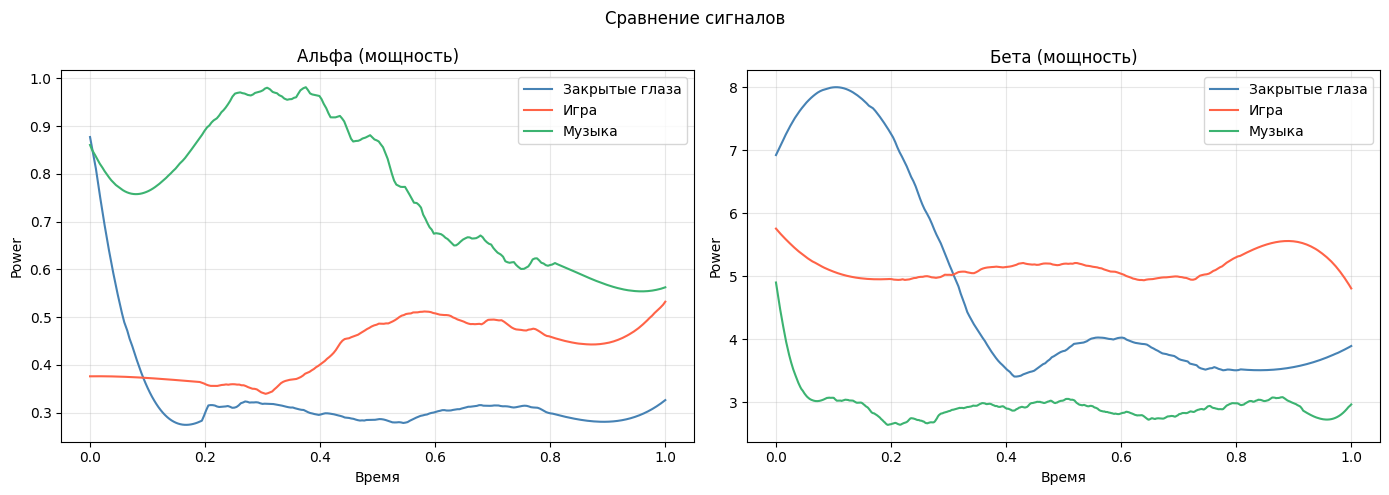

In [ ]:
print("\n Сравнение данных \n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Сравнение сигналов")

for state in ["Закрытые глаза", "Игра", "Музыка"]:
    # Альфа
    df  = clean(load(ALPHA_FILES[state]))
    t   = df["t"].to_numpy()
    t_n = (t - t[0]) / (t[-1] - t[0])
    ax1.plot(t_n[::20], smooth(df["a"].to_numpy())[::20],
             color=COLORS[state], lw=1.2, label=state)

    # Бета
    df  = clean(load(BETA_FILES[state]))
    t   = df["t"].to_numpy()
    fs  = get_fs(t)
    pt, pw = rolling_power(t, df["a"].to_numpy(), fs, BETA_LO, BETA_HI)
    pt_n = (pt - pt[0]) / (pt[-1] - pt[0])
    ax2.plot(pt_n, smooth(pw), color=COLORS[state], lw=1.5, label=state)

ax1.set_title("Альфа волны")
ax1.set_xlabel("Время"); ax1.set_ylabel("Амплитуда, В")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_title("Бета волны")
ax2.set_xlabel("Время"); ax2.set_ylabel("Мощность")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Спектры мощности
Быстрое преобразование Фурье разкладывает весь сигнал по частотам и показывает как распределены данные по частотам. Это усреднённая картина за всё время записи — без динамики, но зато точно показывает на каких именно герцах сосредоточена активность.

Логарифмическая шкала по оси Y нужна потому что мощности на разных частотах
различаются на порядки, в линейной шкале низкочастотные пики подавили бы всё остальное.
Закрашенные зоны показывают альфа и бета диапазоны.


Спектры мощности 



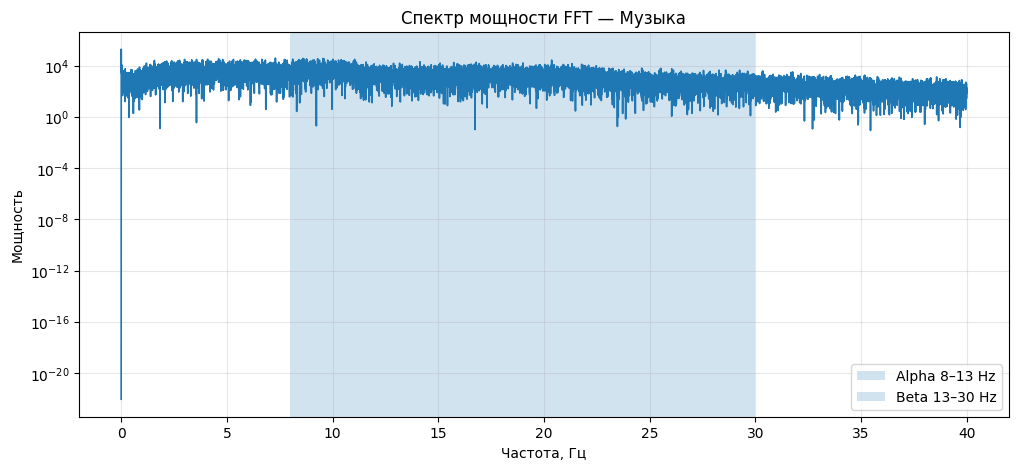


[Закрытые глаза]
Доминирующая частота: 3.00 Гц
Alpha мощность: 4147.39 (145.6% от спектра)
Beta мощность: 2218.91 (77.9% от спектра)
Вывод: преобладают alpha-волны → более расслабленное состояние.

[Игра]
Доминирующая частота: 18.44 Гц
Alpha мощность: 2782.98 (135.3% от спектра)
Beta мощность: 2480.69 (120.6% от спектра)
Вывод: преобладают alpha-волны → более расслабленное состояние.

[Музыка]
Доминирующая частота: 0.00 Гц
Alpha мощность: 5339.96 (218.9% от спектра)
Beta мощность: 1778.24 (72.9% от спектра)
Вывод: преобладают alpha-волны → более расслабленное состояние.


Максимальная alpha-активность наблюдается в состоянии `Музыка`.


In [ ]:
print("\nСпектры мощности \n")

spectrum_rows = []

for state, path in BETA_FILES.items():

    df = clean(load(path))

    t = df["t"].to_numpy()
    a = df["a"].to_numpy()

    fs = get_fs(t)

    freqs, psd = full_spectrum(a, fs)
    mask = freqs <= 40

    freqs = freqs[mask]
    psd   = psd[mask]

    alpha_mask = (freqs >= ALPHA_LO) & (freqs <= ALPHA_HI)
    beta_mask  = (freqs >= BETA_LO)  & (freqs <= BETA_HI)

    alpha_power = psd[alpha_mask].mean()
    beta_power  = psd[beta_mask].mean()

    total_power = psd.mean()

    alpha_percent = 100 * alpha_power / total_power
    beta_percent  = 100 * beta_power  / total_power

    dominant_freq = freqs[np.argmax(psd)]

    spectrum_rows.append({
        "state": state,
        "alpha_power": alpha_power,
        "beta_power": beta_power,
        "alpha_percent": alpha_percent,
        "beta_percent": beta_percent,
        "dominant_freq": dominant_freq
    })


for r in spectrum_rows:

    print(f"\n[{r['state']}]")

    print(
        f"Доминирующая частота: "
        f"{r['dominant_freq']:.2f} Гц"
    )

    print(
        f"Alpha мощность: "
        f"{r['alpha_power']:.2f} "
        f"({r['alpha_percent']:.1f}% от спектра)"
    )

    print(
        f"Beta мощность: "
        f"{r['beta_power']:.2f} "
        f"({r['beta_percent']:.1f}% от спектра)"
    )

    if r["alpha_power"] > r["beta_power"]:
        print(
            "Вывод: преобладают alpha-волны "
            "→ более расслабленное состояние."
        )
    else:
        print(
            "Вывод: преобладают beta-волны "
            "→ более активное/напряжённое состояние."
        )

best_alpha = max(spectrum_rows, key=lambda r: r["alpha_power"])
best_beta  = max(spectrum_rows, key=lambda r: r["beta_power"])

print("\n")

print(
    f"Максимальная alpha-активность наблюдается "
    f"в состоянии `{best_alpha['state']}`."
)

In [ ]:
alpha_sorted = sorted(rows, key=lambda r: r["alpha_mean"], reverse=True)
beta_sorted  = sorted(rows, key=lambda r: r["beta_mean"],  reverse=True)
ratio_sorted = sorted(rows, key=lambda r: r["ratio"],      reverse=True)

print("\n")
print("Анализ сигналов")

print("\nАльфа-мощность по убыванию (расслабление):")
for r in alpha_sorted:
    print(f"  {r['state']:16s}: {r['alpha_mean']:.3f}")

print("\nБета-мощность по убыванию (активность / концентрация):")
for r in beta_sorted:
    print(f"  {r['state']:16s}: {r['beta_mean']:.3f}")

print("\nСоотношение Alpha/Beta (чем выше — тем расслабленнее):")
for r in ratio_sorted:
    print(f"  {r['state']:16s}: {r['ratio']:.3f}")


## Выводы

В ходе работы был проведён анализ ЭЭГ-сигналов для трёх состояний: игра, прослушивание музыки и состояние с закрытыми глазами. Данные были очищены от выбросов и шумов, выполнен спектральный анализ с помощью FFT и рассчитана мощность альфа и бета волн.

Результаты показали, что во время игры сильнее всего проявляются бета волны, что связано с концентрацией, напряжением и работой мозга. При прослушивании музыки наиболее выражены альфа волны, которые обычно связаны с более спокойным и расслабленным состоянием.

Анализ спектров мощности подтвердил эти различия. При игре преобладала активность бета волн в диапазоне 13–30 Гц, а при музыке — в альфа волн в диапазоне 8–13 Гц. Состояние с закрытыми глазами тоже показало активность альфа волн, но немного слабее, что может быть связано с особенностями записи сигнала (шумы, помехи при записи, погрещность измерений).

В целом работа показала, что с помощью спектрального анализа ЭЭГ можно увидеть различия между расслабленным состоянием и состоянием напряжения.